# Logistic Regression Model

A baseline model is trained to identify customers with a higher likelihood of churn.

In [7]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/customer_churn_encoded.csv"
)

df.shape

(7032, 31)

## Feature Selection

The target variable is separated from the predictor variables before training.

In [8]:
X = df.drop("Churn", axis=1)
y = df["Churn"]


## Train-Test Split

The dataset is divided into training and testing samples using an 80/20 split.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Feature Scaling

Numerical variables are standardized before model training.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

## Model Training

I used Logistic Regression is used as a baseline classification model.

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Predictions

Generate churn predictions for the test dataset.

In [12]:
y_pred = model.predict(X_test)

## Model Evaluation

Performance is evaluated using classification metrics.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8045486851457001
Precision: 0.6504559270516718
Recall   : 0.5721925133689839
F1 Score : 0.6088193456614509


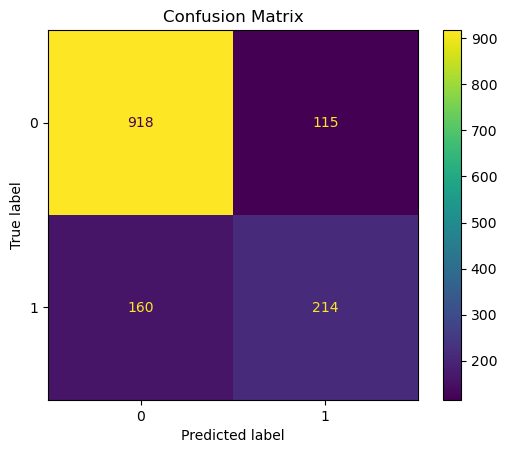

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix")
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Model Performance Summary

The Logistic Regression model achieved:

Accuracy : 0.8045486851457001
Precision: 0.6504559270516718
Recall   : 0.5721925133689839
F1 Score : 0.6088193456614509

The model establishes a baseline for identifying customers at risk of churn.